https://www.tensorflow.org/recommenders/examples/deep_recommenders

In [the featurization tutorial](featurization) we incorporated multiple features into our models, but the models consist of only an embedding layer. We can add more dense layers to our models to increase their expressive power.

In general, deeper models are capable of learning more complex patterns than shallower models. For example, our [user model](featurization#user_model) incorporates user ids and timestamps to model user preferences at a point in time. A shallow model (say, a single embedding layer) may only be able to learn the simplest relationships between those features and movies: a given movie is most popular around the time of its release, and a given user generally prefers horror movies to comedies. To capture more complex relationships, such as user preferences evolving over time, we may need a deeper model with multiple stacked dense layers.

Of course, complex models also have their disadvantages. The first is computational cost, as larger models require both more memory and more computation to fit and serve. The second is the requirement for more data: in general, more training data is needed to take advantage of deeper models. With more parameters, deep models might overfit or even simply memorize the training examples instead of learning a function that can generalize. Finally, training deeper models may be harder, and more care needs to be taken in choosing settings like regularization and learning rate.

Finding a good architecture for a real-world recommender system is a complex art, requiring good intuition and careful [hyperparameter tuning](https://en.wikipedia.org/wiki/Hyperparameter_optimization). For example, factors such as the depth and width of the model, activation function, learning rate, and optimizer can radically change the performance of the model. Modelling choices are further complicated by the fact that good offline evaluation metrics may not correspond to good online performance, and that the choice of what to optimize for is often more critical than the choice of model itself.

Nevertheless, effort put into building and fine-tuning larger models often pays off. In this tutorial, we will illustrate how to build deep retrieval models using TensorFlow Recommenders. We'll do this by building progressively more complex models to see how this affects model performance.

## Preliminaries

We first import the necessary packages.

In [1]:
import os
import tempfile

%matplotlib inline
import matplotlib.pyplot as plt

import numpy as np
import tensorflow as tf
import tensorflow_datasets as tfds

import tensorflow_recommenders as tfrs

plt.style.use('seaborn-whitegrid')

In [2]:
import pandas as pd
import pprint

In this tutorial we will use the models from [the featurization tutorial](featurization) to generate embeddings. Hence we will only be using the user id, timestamp, and movie title features.

In [3]:
def get_broadcaster_data_set(train_ds):
    broadcasters = train_ds.cache().map(lambda x: x["broadcaster"], num_parallel_calls=tf.data.AUTOTUNE, deterministic=False)
    broadcasters_ds = tf.data.Dataset.from_tensor_slices(
        np.unique(list(broadcasters.as_numpy_iterator())))
    return broadcasters_ds


def get_list(training_data, key):
    return training_data.batch(1_000_000).map(lambda x: x[key], num_parallel_calls=tf.data.AUTOTUNE, deterministic=False)


def get_unique_list(data):
    return np.unique(np.concatenate(list(data)))


def load_data_file_cold(file, stats):
    print('loading file:' + file)
    training_df = pd.read_csv(
        file,
        skiprows=[0],
        names=["viewer",
               "broadcaster",
               "viewer_age",
               "viewer_gender",
               "viewer_longitude",
               "viewer_latitude",
               "viewer_lang",
               "viewer_country",
               "broadcaster_age",
               "broadcaster_gender",
               "broadcaster_longitude",
               "broadcaster_latitude",
               "broadcaster_lang",
               "broadcaster_country",
               "duration", 
               "viewer_network", 
               "broadcaster_network", 
               "viewer_lat_long_cluster",
               "rank"], 
        dtype={
            'viewer': np.unicode,
            'broadcaster': np.unicode,
            'viewer_age': np.single,
            'viewer_gender': np.unicode,
            'viewer_longitude': np.single,
            'viewer_latitude': np.single,
            'viewer_lang': np.unicode,
            'viewer_country': np.unicode,
            'broadcaster_age': np.single,
            'broadcaster_longitude': np.single,
            'broadcaster_latitude': np.single,
            'broadcaster_lang': np.unicode,
            'broadcaster_country': np.unicode,
            'viewer_network': np.unicode,
            'broadcaster_network': np.unicode,
            'viewer_lat_long_cluster': np.unicode,
            'rank': np.unicode,
        })

    values = {
        'viewer': 'unknown',
        'broadcaster': 'unknown',
        'viewer_age': 30,
        'viewer_gender': 'unknown',
        'viewer_longitude': 0,
        'viewer_latitude': 0,
        'viewer_lang': 'unknown',
        'viewer_country': 'unknown',
        'broadcaster_age': 30,
        'broadcaster_longitude': 0,
        'broadcaster_latitude': 0,
        'broadcaster_lang': 'unknown',
        'broadcaster_country': 'unknown',
        'duration': 0,
        'viewer_network': 'unknown',
        'broadcaster_network': 'unknown',
        'viewer_lat_long_cluster': '0',
        'rank': '1'
    }
    training_df.fillna(value=values, inplace=True)
    print(training_df.head(10))
    print(training_df.iloc[-10:])
    # stats.send_stats('data-size', len(training_df.index))
    samples = training_df.sample(frac=.1)
    return samples


def load_training_data_cold(file, stats):
    ratings_df = load_data_file_cold(file, stats)
    print('creating data set')
    training_ds = (
        tf.data.Dataset.from_tensor_slices(
            ({
                "viewer": tf.cast(
                    ratings_df['viewer'].values,
                    tf.string),
                "viewer_gender": tf.cast(
                    ratings_df['viewer_gender'].values,
                    tf.string),
                "viewer_lang": tf.cast(
                    ratings_df['viewer_lang'].values,
                    tf.string),
                "viewer_country": tf.cast(
                    ratings_df['viewer_country'].values,
                    tf.string),
                "viewer_age": tf.cast(
                    ratings_df['viewer_age'].values,
                    tf.int32),
                "viewer_longitude": tf.cast(
                    ratings_df['viewer_longitude'].values,
                    tf.float16),
                "viewer_latitude": tf.cast(
                    ratings_df['viewer_latitude'].values,
                    tf.float16),
                "broadcaster": tf.cast(
                    ratings_df['broadcaster'].values,
                    tf.string),
                "viewer_network": tf.cast(
                    ratings_df['viewer_network'].values,
                    tf.string),
                "broadcaster_network": tf.cast(
                    ratings_df['broadcaster_network'].values,
                    tf.string),
                "viewer_lat_long_cluster": tf.cast(
                    ratings_df['viewer_lat_long_cluster'].values,
                    tf.string),
            })))

    return training_ds

def prepare_training_data_cold(train_ds):
    print('prepare_training_data')
    training_ds = train_ds.cache().map(lambda x: {
        "broadcaster": x["broadcaster"],
        "viewer": x["viewer"],
        "viewer_gender": x["viewer_gender"],
        "viewer_lang": x["viewer_lang"],
        "viewer_country": x["viewer_country"],
        "viewer_age": x["viewer_age"],
        "viewer_longitude": x["viewer_longitude"],
        "viewer_latitude": x["viewer_latitude"],
        "viewer_network": x["viewer_network"],
        "broadcaster_network": x["broadcaster_network"],
        "viewer_lat_long_cluster": x["viewer_lat_long_cluster"],
    }, num_parallel_calls=tf.data.AUTOTUNE,
       deterministic=False)

    print('done prepare_training_data')
    return training_ds


def current_milli_time():
    return round(time.time() * 1000)

In [5]:
ratings = load_training_data_cold("../csv/2021-11-22.csv", "")

for x in ratings.take(1).as_numpy_iterator():
    pprint.pprint(x)

loading file:../csv/2021-11-22.csv
                                            viewer  \
0  45 85 43 06 5f e1 cc 1d ad 2b 95 55 59 7f e1 4b   
1  9d 41 ac 98 8b 54 6f 78 50 d4 db 0b d8 fd 80 df   
2  12 02 e1 9b a4 23 af d1 c5 c1 aa d0 05 fa 51 cf   
3  c8 d8 15 6e cf 5b 09 e3 d6 f3 16 9e 9c 05 40 d8   
4  9d 41 ac 98 8b 54 6f 78 50 d4 db 0b d8 fd 80 df   
5  88 3a 7b 32 40 44 eb 66 03 93 e2 93 3b ba 21 14   
6  d4 e6 67 39 64 40 e5 59 93 2b c2 b8 50 de 26 03   
7  e5 98 43 d1 4e 13 aa 68 c7 ba a4 9e 5f 5c 3b 3e   
8  09 10 8b df fb 46 9f 7e c2 93 97 5d 8c 05 72 2c   
9  c8 d8 15 6e cf 5b 09 e3 d6 f3 16 9e 9c 05 40 d8   

                                       broadcaster  viewer_age viewer_gender  \
0  f2 4c 75 ee 7b 35 16 8e db 23 23 62 95 5f e0 d5        26.0          male   
1  88 10 58 1a cf b1 b8 8a 86 92 2e bf 6d 29 6d 30        29.0          male   
2  fd 87 40 b6 5b 39 1f 24 80 bd 9c 37 06 d0 27 74        30.0          male   
3  10 f0 80 30 38 2f 14 08 4c 96 56 c7 cb 49 66 76

creating data set


2021-11-23 10:36:46.227261: I tensorflow/core/platform/cpu_feature_guard.cc:142] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


{'broadcaster': b'90 dd ba ce 96 b3 f2 fa e8 a5 12 96 9d 03 eb ed',
 'broadcaster_network': b'skout',
 'viewer': b'5a 89 9d 34 44 b2 e5 b9 62 89 a7 b9 7d f3 6c 9c',
 'viewer_age': 32,
 'viewer_country': b'IN',
 'viewer_gender': b'male',
 'viewer_lang': b'en',
 'viewer_lat_long_cluster': b'1',
 'viewer_latitude': 24.62,
 'viewer_longitude': 73.7,
 'viewer_network': b'skout'}


In [6]:
broadcasters = ratings.map(lambda x: x["broadcaster"])

Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module 'gast' has no attribute 'Constant'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module 'gast' has no attribute 'Constant'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


In [7]:
for x in broadcasters.take(2).as_numpy_iterator():
    pprint.pprint(x)

b'90 dd ba ce 96 b3 f2 fa e8 a5 12 96 9d 03 eb ed'
b'a6 b3 df 9d 4c c5 dc 39 fd eb f1 e6 7d 5e 53 7b'


2021-11-23 10:37:07.625232: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:176] None of the MLIR Optimization Passes are enabled (registered 2)


In [9]:
train = prepare_training_data_cold(ratings)

prepare_training_data
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module 'gast' has no attribute 'Constant'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module 'gast' has no attribute 'Constant'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
done prepare_training_data


In [10]:
print("get lists")

user_genders = get_list(train, "viewer_gender")
user_langs = get_list(train, "viewer_lang")
user_countries = get_list(train, "viewer_country")
user_networks = get_list(train, "viewer_network")

viewer_age = get_list(train, "viewer_age")
viewer_longitude = get_list(train, "viewer_longitude")
viewer_latitude = get_list(train, "viewer_latitude")

broadcaster_ids = get_list(train, "broadcaster")

data_set_size = len(broadcaster_ids)

get lists
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module 'gast' has no attribute 'Constant'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module 'gast' has no attribute 'Constant'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module 'gast' has no attribute 'Constant'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity

In [15]:
print("get_unique_list")
unique_broadcasters = get_unique_list(broadcaster_ids)
unique_user_genders = get_unique_list(user_genders)
unique_user_langs = get_unique_list(user_langs)
unique_user_countries = get_unique_list(user_countries)
unique_user_networks = get_unique_list(user_networks)
print(unique_broadcasters)

get_unique_list
[b'00 00 20 da f6 46 b2 f6 dc 17 2f 29 f6 94 e0 3a'
 b'00 00 57 d7 03 6d 73 83 3e 58 ec 06 39 87 4a 5f'
 b'00 00 a4 8e cc 01 52 81 dd 45 4e f3 51 f8 f6 b0' ...
 b'ff fe a2 32 2c 3a 25 17 e7 3d 7b ab 39 1e 2a 92'
 b'ff ff 89 02 d8 53 2a be da 73 75 98 fb 4a 03 83'
 b'ff ff d7 35 f3 a8 66 fd 21 7a 78 07 1d 15 0c 78']


In [17]:
user_clusters = get_list(train, "viewer_lat_long_cluster")
unique_user_clusters = get_unique_list(user_clusters)
print(unique_user_clusters)

Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module 'gast' has no attribute 'Constant'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module 'gast' has no attribute 'Constant'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
[b'0' b'1' b'2' b'3' b'4' b'5' b'6' b'7']


In [11]:
broadcaster_ids = ratings.batch(1_00_000).map(lambda x: x["broadcaster"])
unique_broadcaster_ids = np.unique(np.concatenate(list(broadcaster_ids)))
len(unique_broadcaster_ids)

Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module 'gast' has no attribute 'Constant'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module 'gast' has no attribute 'Constant'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


80208

## Model definition

### Query model

We start with the user model defined in [the featurization tutorial](featurization) as the first layer of our model, tasked with converting raw input examples into feature embeddings.

In [12]:
class UserModel(tf.keras.Model) :

    def __init__(self, unique_genders, unique_langs, unique_countries, viewer_age, unique_networks, unique_clusters) :
        super().__init__()

        self.gender_embedding = tf.keras.Sequential([
            tf.keras.layers.experimental.preprocessing.StringLookup(
                vocabulary=unique_genders, mask_token=None),
            tf.keras.layers.Embedding(len(unique_genders) + 1, 4),
        ])

        self.lang_embedding = tf.keras.Sequential([
            tf.keras.layers.experimental.preprocessing.StringLookup(
                vocabulary=unique_langs, mask_token=None),
            tf.keras.layers.Embedding(len(unique_langs) + 1, 10),
        ])

        self.country_embedding = tf.keras.Sequential([
            tf.keras.layers.experimental.preprocessing.StringLookup(
                vocabulary=unique_countries, mask_token=None),
            tf.keras.layers.Embedding(len(unique_countries) + 1, 10),
        ])

        self.network_embedding = tf.keras.Sequential([
            tf.keras.layers.experimental.preprocessing.StringLookup(
                vocabulary=unique_networks, mask_token=None),
            tf.keras.layers.Embedding(len(unique_networks) + 1, 4),
        ])

        age_boundaries = np.array([18, 25, 30, 35, 40, 45, 50, 55, 60, 65, float("inf")])
        self.viewer_age_embedding = tf.keras.Sequential([
            tf.keras.layers.experimental.preprocessing.Discretization(age_boundaries.tolist()),
            tf.keras.layers.Embedding(len(age_boundaries), 2)
        ])
        
        self.viewer_lat_long_embedding = tf.keras.Sequential([
            tf.keras.layers.experimental.preprocessing.StringLookup(
                vocabulary=unique_clusters, mask_token=None),
            tf.keras.layers.Embedding(len(unique_clusters) + 1, 2),
        ])


    def call(self, inputs) :
        return tf.concat([
            self.gender_embedding(inputs["viewer_gender"]),
            self.lang_embedding(inputs["viewer_lang"]),
            self.country_embedding(inputs["viewer_country"]),
            self.network_embedding(inputs["viewer_network"]),
            self.viewer_age_embedding(inputs["viewer_age"]),
            self.viewer_lat_long_embedding(inputs["viewer_lat_long_cluster"]),
        ], axis = 1)

In [21]:
user_model = UserModel(unique_user_genders, unique_user_langs, unique_user_countries, viewer_age, unique_user_networks, unique_user_clusters)

Defining deeper models will require us to stack mode layers on top of this first input. A progressively narrower stack of layers, separated by an activation function, is a common pattern:

```
                            +----------------------+
                            |      128 x 64        |
                            +----------------------+
                                       | relu
                          +--------------------------+
                          |        256 x 128         |
                          +--------------------------+
                                       | relu
                        +------------------------------+
                        |          ... x 256           |
                        +------------------------------+
```
Since the expressive power of deep linear models is no greater than that of shallow linear models, we use ReLU activations for all but the last hidden layer. The final hidden layer does not use any activation function: using an activation function would limit the output space of the final embeddings and might negatively impact the performance of the model. For instance, if ReLUs are used in the projection layer, all components in the output embedding would be non-negative.

We're going to try something similar here. To make experimentation with different depths easy, let's define a model whose depth (and width) is defined by a set of constructor parameters. 

In [22]:
class QueryModel ( tf.keras.Model ):
	"""Model for encoding user queries."""

	def __init__ ( self , layer_sizes, unique_user_genders, unique_user_langs, unique_user_countries, viewer_age, unique_user_networks, unique_user_clusters):
		"""Model for encoding user queries.

		Args:
		  layer_sizes:
			A list of integers where the i-th entry represents the number of units
			the i-th layer contains.
		"""
		super( ).__init__( )

		# We first use the user model for generating embeddings.
		self.embedding_model = UserModel(unique_user_genders, unique_user_langs, unique_user_countries, viewer_age, unique_user_networks, unique_user_clusters)

		# Then construct the layers.
		self.dense_layers = tf.keras.Sequential( )

		# Use the ReLU activation for all but the last layer.
		for layer_size in layer_sizes [ :-1 ]:
			self.dense_layers.add ( tf.keras.layers.Dense ( layer_size , activation = "relu" ) )

		# No activation for the last layer.
		for layer_size in layer_sizes [ -1: ]:
			self.dense_layers.add ( tf.keras.layers.Dense ( layer_size ) )

	def call ( self , inputs ):
		feature_embedding = self.embedding_model ( inputs )
		return self.dense_layers ( feature_embedding )

The `layer_sizes` parameter gives us the depth and width of the model. We can vary it to experiment with shallower or deeper models.

### Candidate model

We can adopt the same approach for the movie model. Again, we start with the `MovieModel` from the [featurization](featurization) tutorial:

In [23]:
broadcaster_ids = ratings.batch(100_000).map(lambda x: x["broadcaster"])
unique_broadcaster_ids = np.unique(np.concatenate(list(broadcaster_ids)))

Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module 'gast' has no attribute 'Constant'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module 'gast' has no attribute 'Constant'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


In [24]:
len(unique_broadcaster_ids )

80208

In [46]:
class BroadcasterModel(tf.keras.Model):

    def __init__(self, unique_broadcaster_ids, dims):
        super().__init__()

        self.broadcaster_embedding = tf.keras.Sequential([
            tf.keras.layers.experimental.preprocessing.StringLookup(
                vocabulary=unique_broadcaster_ids, mask_token=None),
            tf.keras.layers.Embedding(len(unique_broadcaster_ids) + 1, dims)
        ])

    def call(self, broadcaster):
        return tf.concat([
            self.broadcaster_embedding(broadcaster),
        ], axis=1)

And expand it with hidden layers:

In [47]:
class CandidateModel(tf.keras.Model):
	"""Model for encoding movies."""

	def __init__(self, layer_sizes, unique_broadcaster_titles, dims):
		"""Model for encoding movies.
	
		Args:
		  layer_sizes:
			A list of integers where the i-th entry represents the number of units
			the i-th layer contains.
		"""
		super().__init__()

		self.embedding_model = BroadcasterModel(unique_broadcaster_titles, dims)

		# Then construct the layers.
		self.dense_layers = tf.keras.Sequential()

		# Use the ReLU activation for all but the last layer.
		for layer_size in layer_sizes[:-1]:
			self.dense_layers.add(tf.keras.layers.Dense(layer_size, activation="relu"))

		# No activation for the last layer.
		for layer_size in layer_sizes[-1:]:
			self.dense_layers.add(tf.keras.layers.Dense(layer_size))

	def call(self, inputs):
		feature_embedding = self.embedding_model(inputs)
		return self.dense_layers(feature_embedding)

### Combined model

With both `QueryModel` and `CandidateModel` defined, we can put together a combined model and implement our loss and metrics logic. To make things simple, we'll enforce that the model structure is the same across the query and candidate models.

In [48]:
class FinalModel ( tfrs.models.Model ):

	def __init__ ( self , layer_sizes, unique_user_genders, unique_user_langs, unique_user_countries, viewer_age, unique_user_networks, unique_user_clusters, unique_broadcaster_ids, dims):
		super ( ).__init__ ( )
		self.query_model = QueryModel(layer_sizes, unique_user_genders, unique_user_langs, unique_user_countries, viewer_age, unique_user_networks, unique_user_clusters)
		self.candidate_model = CandidateModel ( layer_sizes, unique_broadcaster_ids, dims)
		self.task = tfrs.tasks.Retrieval (
			metrics = tfrs.metrics.FactorizedTopK (
				candidates = broadcasters.batch ( 128 ).map ( self.candidate_model ) ,
			) ,
		)

	def compute_loss ( self , features , training = False ):
		# We only pass the user id and timestamp features into the query model. This
		# is to ensure that the training inputs would have the same keys as the
		# query inputs. Otherwise the discrepancy in input structure would cause an
		# error when loading the query model after saving it.
		query_embeddings = self.query_model ( {
            "viewer_gender": features["viewer_gender"],
                "viewer_lang": features["viewer_lang"],
                "viewer_country": features["viewer_country"],
                "viewer_age": features["viewer_age"],
                "viewer_network": features["viewer_network"],
                "viewer_latitude": features["viewer_latitude"],
                "viewer_longitude": features["viewer_longitude"],
                "viewer_lat_long_cluster": features["viewer_lat_long_cluster"]
		} )
        
		positive_broadcaster_embeddings = self.candidate_model ( features [ "broadcaster" ] )

		return self.task (
			query_embeddings , positive_broadcaster_embeddings , compute_metrics = not training )

## Training the model

### Prepare the data

We first split the data into a training set and a testing set.

In [49]:
tf.random.set_seed(42)
shuffled = ratings.shuffle(100_000, seed=42, reshuffle_each_iteration=False)

train = shuffled.take(80_000)
test = shuffled.skip(80_000).take(20_000)

cached_train = train.shuffle(100_000).batch(2048)
cached_test = test.batch(4096).cache()

### Shallow model

We're ready to try out our first, shallow, model!

In [58]:
num_epochs = 3

model = FinalModel([32], unique_user_genders, unique_user_langs, unique_user_countries, viewer_age, unique_user_networks, unique_user_clusters, unique_broadcaster_ids, 32)
model.compile(optimizer=tf.keras.optimizers.Adagrad(0.1))

model.fit(cached_train, epochs=3)

train_accuracy = model.evaluate(
    cached_train, return_dict=True)["factorized_top_k/top_100_categorical_accuracy"]
test_accuracy = model.evaluate(
    cached_test, return_dict=True)["factorized_top_k/top_100_categorical_accuracy"]

print(f"Top-100 accuracy (train): {train_accuracy:.2f}.")
print(f"Top-100 accuracy (test): {test_accuracy:.2f}.")


one_layer_history = model.fit(
    cached_train,
    validation_data=cached_test,
    validation_freq=5,
    epochs=num_epochs,
    verbose=0)

accuracy = one_layer_history.history["factorized_top_k/top_100_categorical_accuracy"][-1]
print(f"Top-100 accuracy: {accuracy:.2f}.")

Epoch 1/3
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
40/40 [==============================] - 5s 69ms/step - factorized_top_k/top_1_categorical_accuracy: 0.0000e+00 - factorized_top_k/top_5_categorical_accuracy: 0.0000e+00 - factorized_top_k/top_10_categorical_accuracy: 0.0000e+00 - factorized_top_k/top_50_categorical_accuracy: 0.0000e+00 - factorized_top_k/top_100_categorical_accuracy: 0.0000e+00 - loss: 14456.9429 -

This gives us a top-100 accuracy of around 0.27. We can use this as a reference point for evaluating deeper models.



### Deeper model

What about a deeper model with two layers?

In [59]:
model = FinalModel([64, 32], unique_user_genders, unique_user_langs, unique_user_countries, viewer_age, unique_user_networks, unique_user_clusters, unique_broadcaster_ids, 32)
model.compile(optimizer=tf.keras.optimizers.Adagrad(0.1))

model.fit(cached_train, epochs=3)

train_accuracy = model.evaluate(
    cached_train, return_dict=True)["factorized_top_k/top_100_categorical_accuracy"]
test_accuracy = model.evaluate(
    cached_test, return_dict=True)["factorized_top_k/top_100_categorical_accuracy"]

print(f"Top-100 accuracy (train): {train_accuracy:.2f}.")
print(f"Top-100 accuracy (test): {test_accuracy:.2f}.")


two_layer_history = model.fit(
    cached_train,
    validation_data=cached_test,
    validation_freq=5,
    epochs=num_epochs,
    verbose=0)

accuracy = two_layer_history.history["factorized_top_k/top_100_categorical_accuracy"][-1]
print(f"Top-100 accuracy: {accuracy:.2f}.")

Epoch 1/3
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
40/40 [==============================] - 5s 69ms/step - factorized_top_k/top_1_categorical_accuracy: 0.0000e+00 - factorized_top_k/top_5_categorical_accuracy: 0.0000e+00 - factorized_top_k/top_10_categorical_accuracy: 0.0000e+00 - factorized_top_k/top_50_categorical_accuracy: 0.0000e+00 - factorized_top_k/top_100_categorical_accuracy: 0.0000e+00 - loss: 14769.2177 -

The accuracy here is 0.29, quite a bit better than the shallow model.

We can plot the validation accuracy curves to illustrate this:

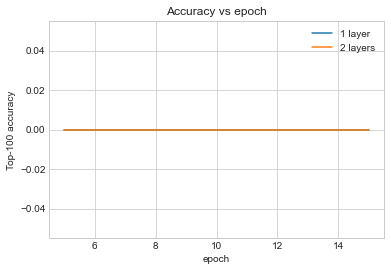

In [61]:
num_validation_runs = len(one_layer_history.history["factorized_top_k/top_100_categorical_accuracy"])
epochs = [(x + 1)* 5 for x in range(num_validation_runs)]

plt.plot(epochs, one_layer_history.history["factorized_top_k/top_100_categorical_accuracy"], label="1 layer")
plt.plot(epochs, two_layer_history.history["factorized_top_k/top_100_categorical_accuracy"], label="2 layers")
plt.title("Accuracy vs epoch")
plt.xlabel("epoch")
plt.ylabel("Top-100 accuracy");
plt.legend()

Even early on in the training, the larger model has a clear and stable lead over the shallow model, suggesting that adding depth helps the model capture more nuanced relationships in the data.

However, even deeper models are not necessarily better. The following model extends the depth to three layers:

In [66]:
model = FinalModel([128, 64, 32], unique_user_genders, unique_user_langs, unique_user_countries, viewer_age, unique_user_networks, unique_user_clusters, unique_broadcaster_ids, 32)
model.compile(optimizer=tf.keras.optimizers.Adagrad(0.1))

model.fit(cached_train, epochs=3)

train_accuracy = model.evaluate(
    cached_train, return_dict=True)["factorized_top_k/top_100_categorical_accuracy"]
test_accuracy = model.evaluate(
    cached_test, return_dict=True)["factorized_top_k/top_100_categorical_accuracy"]

print(f"Top-100 accuracy (train): {train_accuracy:.2f}.")
print(f"Top-100 accuracy (test): {test_accuracy:.2f}.")

three_layer_history = model.fit(
    cached_train,
    validation_data=cached_test,
    validation_freq=5,
    epochs=num_epochs,
    verbose=0)

accuracy = three_layer_history.history["factorized_top_k/top_100_categorical_accuracy"][-1]
print(f"Top-100 accuracy: {accuracy:.2f}.")


Epoch 1/3
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
40/40 [==============================] - 4s 69ms/step - factorized_top_k/top_1_categorical_accuracy: 0.0000e+00 - factorized_top_k/top_5_categorical_accuracy: 0.0000e+00 - factorized_top_k/top_10_categorical_accuracy: 0.0000e+00 - factorized_top_k/top_50_categorical_accuracy: 0.0000e+00 - factorized_top_k/top_100_categorical_accuracy: 0.0000e+00 - loss: 17790.9771 -

In fact, we don't see improvement over the shallow model:

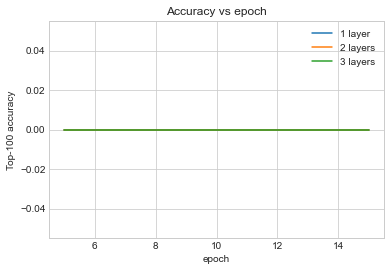

In [67]:
plt.plot(epochs, one_layer_history.history["factorized_top_k/top_100_categorical_accuracy"], label="1 layer")
plt.plot(epochs, two_layer_history.history["factorized_top_k/top_100_categorical_accuracy"], label="2 layers")
plt.plot(epochs, three_layer_history.history["factorized_top_k/top_100_categorical_accuracy"], label="3 layers")
plt.title("Accuracy vs epoch")
plt.xlabel("epoch")
plt.ylabel("Top-100 accuracy");
plt.legend()

This is a good illustration of the fact that deeper and larger models, while capable of superior performance, often require very careful tuning. For example, throughout this tutorial we used a single, fixed learning rate. Alternative choices may give very different results and are worth exploring. 

With appropriate tuning and sufficient data, the effort put into building larger and deeper models is in many cases well worth it: larger models can lead to substantial improvements in prediction accuracy.



## Next Steps

In this tutorial we expanded our retrieval model with dense layers and activation functions. To see how to create a model that can perform not only retrieval tasks but also rating tasks, take a look at [the multitask tutorial](multitask).